# Day 2 NYC School Analysis

In [28]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading the dataset

In [5]:
df = pd.read_csv('high-school-directory.csv')

# Cleaning the Column names

In [4]:
import re  #imports the regular expressions module

df.columns = (
    df.columns
      .str.lower()
      .str.replace(' ', '_', regex=False)
      .str.replace(r'[^a-z0-9_]', '', regex=True)
)

In [8]:
#Filtering the dataset to include only schools located in Brooklyn

brooklyn_df = df[df['borough'].str.strip().str.lower() == 'brooklyn'] 

In [7]:
brooklyn_df

,dbn,school_name,borough,building_code,phone_number,fax_number,grade_span_min,grade_span_max,expgrade_span_min,expgrade_span_max,...,Council District,Census Tract,BIN,BBL,NTA,Zip Codes,Community Districts,Borough Boundaries,City Council Districts,Police Precincts
1,21K559,Life Academy High School for Film and Music,Brooklyn,K400,718-333-7750,718-333-7775,9.0,12,NaN,NaN,...,47.0,306.0,3186454.0,3.068830e+09,Gravesend ...,17616.0,21,2,45,35
2,16K393,Frederick Douglass Academy IV Secondary School,Brooklyn,K026,718-574-2820,718-574-2821,9.0,12,NaN,NaN,...,36.0,291.0,3393805.0,3.016160e+09,Stuyvesant Heights ...,18181.0,69,2,49,52
7,17K122,Pathways in Technology Early College High Scho...,Brooklyn,K625,718-221-1593,718-221-1781,9.0,12,9.0,14.0,...,36.0,311.0,3030553.0,3.012160e+09,Crown Heights North ...,17615.0,16,2,49,49
10,23K644,Eagle Academy for Young Men II,Brooklyn,K271,718-495-0863,718-732-2129,6.0,12,NaN,NaN,...,41.0,301.0,3042157.0,3.015500e+09,Ocean Hill ...,13516.0,55,2,17,46
12,15K462,Secondary School for Law,Brooklyn,K460,718-832-4250,718-499-3947,9.0,12,NaN,NaN,...,39.0,155.0,3025510.0,3.010820e+09,Park Slope-Gowanus ...,17617.0,14,2,27,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
422,17K524,International High School at Prospect Heights,Brooklyn,K440,718-230-6333,718-230-6322,9.0,12,NaN,NaN,...,35.0,213.0,3029686.0,3.011870e+09,Crown Heights South ...,13509.0,17,2,48,44
423,17K408,Academy of Hospitality and Tourism,Brooklyn,K465,718-564-2580,718-564-2581,9.0,12,NaN,NaN,...,40.0,794.0,3336215.0,3.051030e+09,Erasmus ...,13510.0,60,2,11,43
427,15K592,Khalil Gibran International Academy,Brooklyn,K806,718-237-2502,718-488-1724,9.0,12,NaN,NaN,...,33.0,39.0,3331754.0,3.001740e+09,DUMBO-Vinegar Hill-Downtown Brooklyn-Boerum Hi...,17619.0,68,2,38,54
432,32K549,Bushwick School for Social Justice,Brooklyn,K480,718-381-7100,718-418-0192,9.0,12,NaN,NaN,...,37.0,435.0,3076908.0,3.033650e+09,Bushwick North ...,18181.0,42,2,37,53


**Question 1:** How many total schools are in Brooklyn?  
Answer: 121 schools

In [12]:
#Unique schools in Brooklyn df
brooklyn_df["dbn"].nunique()

121

**Question 2:** How many schools in Brooklyn offer Grade 9 entry?  
Answer: **121** schools (All Brooklyn schools include Grade 9 )

In [14]:
#null check
brooklyn_df[["grade_span_min", "grade_span_max"]].isna().sum()

grade_span_min    0
grade_span_max    0
dtype: int64

In [16]:
#Filter for grade9
brooklyn_df_grade9 = brooklyn_df[
    (brooklyn_df["grade_span_min"] <= 9) &
    (brooklyn_df["grade_span_max"] >= 9)
]

#Number of grade9 schools check
len(brooklyn_df_grade9)

121

# Group and summarize:

In [17]:
#unique schools per borough
schools_per_borough = (
    df.groupby("borough")["dbn"]
      .nunique()
      .sort_values(ascending=False)
)

schools_per_borough

borough
Brooklyn         121
Bronx            118
Manhattan        106
Queens            80
Staten Island     10
Name: dbn, dtype: int64

In [18]:
#Average number of students per borough
avg_students_per_borough = (
    df.groupby("borough")["total_students"]
      .mean()
      .round(1)
      .sort_values(ascending=False)
)

avg_students_per_borough

borough
Staten Island    1847.5
Queens           1046.6
Brooklyn          699.1
Manhattan         589.8
Bronx             490.4
Name: total_students, dtype: float64

In [19]:
#Summary of grade_span_max grouped by borough
grade_span_summary = (
    df.groupby("borough")["grade_span_max"]
      .describe()
)

grade_span_summary

,count,mean,std,min,25%,50%,75%,max
borough,,,,,,,,
Bronx,118.0,11.906780,0.369506,9.0,12.0,12.0,12.0,12.0
Brooklyn,121.0,11.933884,0.381566,9.0,12.0,12.0,12.0,12.0
Manhattan,106.0,11.877358,0.472135,9.0,12.0,12.0,12.0,12.0
Queens,80.0,11.825000,0.497462,10.0,12.0,12.0,12.0,12.0
Staten Island,10.0,12.000000,0.000000,12.0,12.0,12.0,12.0,12.0


# Visualization

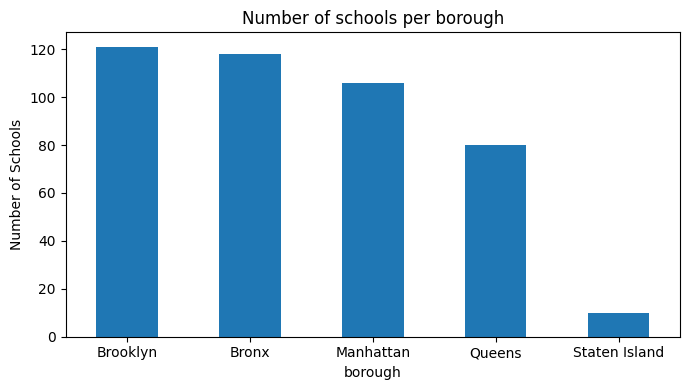

In [ ]:
#Bar chart — Number of schools per borough
schools_per_borough.plot(kind="bar", figsize=(7,4))
plt.title("Number of schools per borough")
plt.xlabel("borough")
plt.ylabel("Number of Schools")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

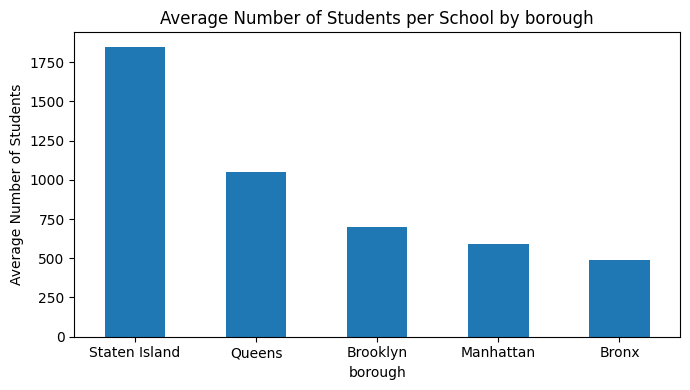

In [ ]:
#Bar chart - Average number of students per borough
avg_students_per_borough.plot(kind="bar", figsize=(7,4))
plt.title("Average Number of Students per School by borough")
plt.xlabel("borough")
plt.ylabel("Average Number of Students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Key Insights
 1. Brooklyn and the Bronx have the highest number of schools, with 121 and 118 schools respectively, while Staten Island has significantly fewer schools (10), indicating a much smaller school footprint compared to other boroughs.

 2. Average student enrollment per school varies notably by borough: Staten Island and Queens have the highest average number of students per school, whereas the Bronx has the lowest, suggesting differences in school size and capacity across boroughs.

 3. The maximum grade offered is highly consistent across boroughs, with most schools extending to Grade 12. Staten Island stands out in that all schools there exclusively serve up to Grade 12, while other boroughs include a small number of schools ending at lower grades.